# load file

In [1]:
# load the project root into the notebook to be able to load functions from other modules
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "tests":
    PROJECT_ROOT = PROJECT_ROOT.parent.parent

sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
from scipy.io import loadmat
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os 
from Base.Opensim_analysis_code import get_angle_data, angle_plot, analyze_folder_OS

print(os.getcwd())

/Users/ernstdavidts/Library/CloudStorage/OneDrive-UGent/Master I/Oslo/Curved_Running_Pilot/Base/tests
/Users/ernstdavidts/Library/CloudStorage/OneDrive-UGent/Master I/Oslo/Curved_Running_Pilot/Base/tests


In [3]:
GRF = loadmat("../../files/OpenSim/MN_Shoe25OpenSim_python.mat")
GRF
# GRF = GRF["GRF_TABLE"]
# print(GRF)

{'__header__': b'MATLAB 5.0 MAT-file, Platform: PCWIN64, Created on: Wed Mar 18 08:38:13 2026',
 '__version__': '1.0',
 '__globals__': [],
 'ANGLES_TABLE': array([[(array([[ 0.00000000e+00,  1.10860301e+01, -1.11484122e+01, ...,
                  4.65310292e+01,  0.00000000e+00,  0.00000000e+00],
                [ 1.00000000e-02,  1.08289914e+01, -1.05842464e+01, ...,
                  4.65118479e+01,  0.00000000e+00,  0.00000000e+00],
                [ 2.00000000e-02,  1.05723479e+01, -1.01023820e+01, ...,
                  4.64861227e+01,  0.00000000e+00,  0.00000000e+00],
                ...,
                [ 6.40000000e-01,  1.21042126e+01, -6.91395990e+00, ...,
                  4.55928044e+01,  0.00000000e+00,  0.00000000e+00],
                [ 6.50000000e-01,  1.49846762e+01, -9.76181816e+00, ...,
                  4.54847635e+01,  0.00000000e+00,  0.00000000e+00],
                [ 6.60000000e-01,  1.78656945e+01, -1.58505979e+01, ...,
                  4.53680230e+01,  0.000

In [4]:
angle = get_angle_data("../../files/OpenSim/ED_Shoe25OpenSim_python.mat", "../../files/angles_with_labels")
OS = analyze_folder_OS("../../files/OpenSim")
pelvis = OS["pelvis_tilt"]
new = pelvis[pelvis["shoe"] == "45"]
new2 = new[new["condition"] == "Curve"]
new2


# pelvis = OS["pelvis_tilt"]

# Ernst = pelvis[pelvis["participant"] == "ED"]
# Ernst


,participant,shoe,condition,trial,time,value,side
0,MN,45,Curve,1,0.00,12.723798,None
1,MN,45,Curve,1,0.01,12.843295,None
2,MN,45,Curve,1,0.02,12.695810,None
3,MN,45,Curve,1,0.03,12.377235,None
4,MN,45,Curve,1,0.04,11.854617,None
...,...,...,...,...,...,...,...
70,ED,45,Curve,5,0.70,5.275085,None
71,ED,45,Curve,5,0.71,5.670511,None
72,ED,45,Curve,5,0.72,5.896407,None
73,ED,45,Curve,5,0.73,6.068047,None


  participant shoe condition trial
0          ED   25     Curve     1
0          ED   25     Curve     2
0          ED   25     Curve     3
0          ED   25     Curve     4
0          ED   25     Curve     5
0          ED   25  Straight     1
0          ED   25  Straight     2
0          ED   25  Straight     3
0          ED   25  Straight     4
0          ED   25  Straight     5
participant  shoe  condition  trial
ED           25    Curve      1        67
                              2        69
                              3        81
                              4        89
                              5        85
                   Straight   1        78
                              2        77
                              3        56
                              4        78
                              5        73
dtype: int64


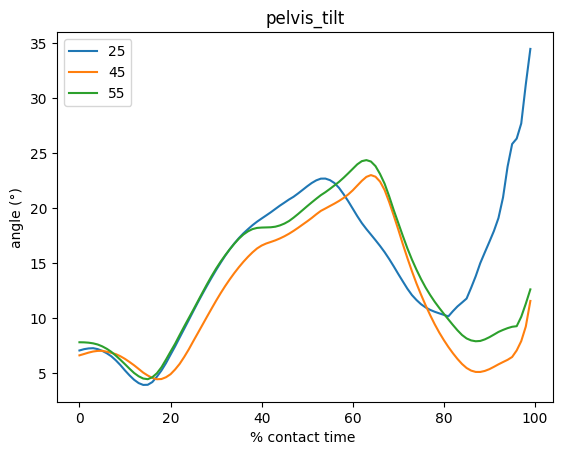

In [5]:
tmp = OS["ankle_angle_r"]
tmp = tmp[(tmp["participant"] == "ED") & (tmp["shoe"] == "25")]
print(tmp[["participant", "shoe", "condition", "trial"]].drop_duplicates())
print(tmp.groupby(["participant", "shoe", "condition", "trial"]).size())

angle_plot(OS, joint= "pelvis_tilt", participant="ED", comparison="shoe", condition="Curve", side=None)

In [6]:
def get_angle_data(data, joint, trial="Curve_1", specification="Rotation", header="ANGLES_TABLE"):
    type_data = data[header][0,0]
    trial_data = type_data[f"x25_{trial}_mat"]

    angle_dict_local = {labels[n]: trial_data[:, n] for n in range(len(labels))}
    x = trial_data[:, 0]

    if joint in ["ankle", "knee"]:
        y_l = [angle_dict_local[k] for k in angle_dict_local.keys() if joint in k and k.endswith("_l")][0]
        y_r = [angle_dict_local[k] for k in angle_dict_local.keys() if joint in k and k.endswith("_r")][0]
        return x, y_l, y_r

    elif joint == "hip":
        y_l = [angle_dict_local[k] for k in angle_dict_local.keys() if specification.lower() in k and k.endswith("_l")][0]
        y_r = [angle_dict_local[k] for k in angle_dict_local.keys() if specification.lower() in k and k.endswith("_r")][0]
        return x, y_l, y_r

    else:
        y = [angle_dict_local[k] for k in angle_dict_local.keys() if joint in k and specification.lower() in k][0]
        return x, y